# 02 · Politicians × Instagram

Built on `polarization.py`. Writes `user_counts.csv`, `channel_df.csv`, `video_df.csv`.

Instagram posts map onto the YouTube schema: post → `video_id`, account → `channel_id`.

In [1]:
import sys
sys.path.append(".")          # polarization.py sits next to this notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import polarization as P

In [13]:
from pathlib import Path

ROOT = Path("dataset")

In [ ]:
PLATFORM      = "Instagram"
PRODUCER_TYPE = "Politician"

OUT = ROOT/"politicians"/"instagram"

## 1. Load comments

In [3]:
df = P.flatten_instagram_comments(
    "D:/School/2026 Spring/independent_study/datasets/politicians/instagram/posts.json",
    "D:/School/2026 Spring/independent_study/datasets/politicians/instagram/comments.json",
)

print(df.shape)
df.head()

  319,882 rows -> 118 MB in memory
(319882, 12)


,video_id,video_title,channel_id,channel_name,channel_url,post_timestamp,comment_id,parent_id,type,author,like_count,timestamp
0,DXwXyojoJYo,[기후테크의 날👍🏻 26.04.30]\n기후대응은 기후테크로! \n#2026기후테크...,66297441760,soheekim_official,https://www.instagram.com/soheekim_official/,2026-04-30T12:28:12.000Z,17924379039299698,None,comment,microalgae0605,0.0,2026-05-01T02:34:02.000Z
1,DXwXyojoJYo,[기후테크의 날👍🏻 26.04.30]\n기후대응은 기후테크로! \n#2026기후테크...,66297441760,soheekim_official,https://www.instagram.com/soheekim_official/,2026-04-30T12:28:12.000Z,17945416638175529,None,comment,soheekim_official,0.0,2026-04-30T12:31:09.000Z
2,DXs4IWhk66m,"〈경기도, 반드시 이깁니다〉\n\n오늘, 더불어민주당 경기도당\n지역위원회 현안 간...",31374252666,with_hanjuno,https://www.instagram.com/with_hanjuno/,2026-04-29T03:53:49.000Z,18079668683550300,None,comment,k.s.y.4091,2.0,2026-04-29T04:08:48.000Z
3,DXs4IWhk66m,"〈경기도, 반드시 이깁니다〉\n\n오늘, 더불어민주당 경기도당\n지역위원회 현안 간...",31374252666,with_hanjuno,https://www.instagram.com/with_hanjuno/,2026-04-29T03:53:49.000Z,17884472679519789,None,comment,yangjeonghun37,19.0,2026-04-29T04:48:20.000Z
4,DXs4IWhk66m,"〈경기도, 반드시 이깁니다〉\n\n오늘, 더불어민주당 경기도당\n지역위원회 현안 간...",31374252666,with_hanjuno,https://www.instagram.com/with_hanjuno/,2026-04-29T03:53:49.000Z,18103222726975957,None,comment,ssicalove7,9.0,2026-04-29T04:51:22.000Z


In [4]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True,
    errors="coerce"
)

print("Earliest:", df["timestamp"].min())
print("Latest:", df["timestamp"].max())

Earliest: 2016-04-01 07:01:07+00:00
Latest: 2026-05-27 07:51:24+00:00


In [5]:
summary = pd.DataFrame({
    "Total": [
        df["channel_id"].nunique(),
        df["video_id"].nunique(),
        df["comment_id"].nunique(),
        df["author"].nunique()
    ]
}, index=[
    "Channels",
    "Videos",
    "Comments",
    "Users"
])

summary

,Total
Channels,82
Videos,14203
Comments,147982
Users,43884


In [4]:
df["type"].value_counts()

type
comment    319850
reply          32
Name: count, dtype: int64

### Were replies actually collected?

The scraper reports `repliesCount` but often returns an empty `replies` array.
If almost nothing was collected, Instagram reply threads are effectively
missing from this cell — worth stating rather than discovering later.

In [6]:
import json

with open(f"D:/School/2026 Spring/independent_study/datasets/politicians/instagram/comments.json", "r", encoding="utf-8") as f:
    _raw = json.load(f)

print("repliesCount total:", sum((c.get("repliesCount") or 0) for c in _raw))
print("replies collected :", sum(len(c.get("replies") or []) for c in _raw))

del _raw

repliesCount total: 12190
replies collected : 32


## 2. Ideology lookup

In [7]:
ideo = P.politician_ideology(r"D:/School/2026 Spring/KR_Polarization/dataset/22ndKRHouseRepMembers.xlsx", PLATFORM)

ideo.head()

  ideology map (Instagram): 260 producers -> {'left': 166, 'right': 89, 'independent': 5}


,key,producer_name,ideology
0,grace.kang.165,강경숙,left
1,kangds88,강대식,right
2,deukgu_kang,강득구,left
3,myounggu_kang,강명구,right
4,minkukkang,강민국,right


In [8]:
ideo["ideology"].value_counts()

ideology
left           166
right           89
independent      5
Name: count, dtype: int64

## 3. Prepare

Dedupe on `comment_id`, attach ideology, drop producer self-comments, fold
`independent` into left. Read the printout: a low match rate means the lookup
keys don't line up, and a big drop at the dedupe step means the source file
holds each record more than once.

In [9]:
prepared = P.prepare(df, ideo, PLATFORM)

  dedupe on comment_id: 319,882 -> 147,982
  ideology matched: 147,934 / 147,982 (100.0%)
  top unmatched producers:
    minsimman: 25
    kimjongmin_in_field: 16
    sljise_mami: 7
  self-comments dropped: 322
  independent -> left: 18,139


## 4. User-level measures

In [11]:
uc_5, _ = P.user_measures(prepared, min_comments=5)
uc_10, _ = P.user_measures(prepared, min_comments=10)
uc_20, _ = P.user_measures(prepared, min_comments=20)

  authors: 43,823 | active (>=5): 5,940 | comments kept: 90,571
  users on >1 producer: 3,848 / 5,940 (64.8%)
  authors: 43,823 | active (>=10): 2,463 | comments kept: 68,296
  users on >1 producer: 1,763 / 2,463 (71.6%)
  authors: 43,823 | active (>=20): 980 | comments kept: 48,674
  users on >1 producer: 785 / 980 (80.1%)


In [12]:
for threshold, uc in [
    (5, uc_5),
    (10, uc_10),
    (20, uc_20)
]:
    # Add labels
    uc["producer_type"] = PRODUCER_TYPE
    uc["platform"] = PLATFORM

    # Verify labels
    pt = set(uc["producer_type"])
    pl = set(uc["platform"])

    assert pt == {PRODUCER_TYPE}
    assert pl == {PLATFORM}

    # Save
    uc.to_csv(
        f"{OUT}/user_counts_{threshold}.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"user_counts_{threshold}: "
        f"{len(uc):,} users | {pt} | {pl} | saved"
    )

user_counts_5: 5,940 users | {'Politician'} | {'Instagram'} | saved
user_counts_10: 2,463 users | {'Politician'} | {'Instagram'} | saved
user_counts_20: 980 users | {'Politician'} | {'Instagram'} | saved


In [10]:
user_counts, comment_users = P.user_measures(prepared, min_comments=P.MIN_COMMENTS)

user_counts = P.tag(user_counts, PLATFORM, PRODUCER_TYPE)
user_counts.head()

  authors: 43,823 | active (>=20): 980 | comments kept: 48,674
  users on >1 producer: 785 / 980 (80.1%)


,author,left,right,user_bias,user_cross_cut,total,n_producers,activity_band,platform,producer_type
0,01.074140998,34,0,-1.0,0.0,34,3,20–49,Instagram,Politician
1,02rmsgur,20,0,-1.0,0.0,20,1,20–49,Instagram,Politician
2,0503alfk,31,0,-1.0,0.0,31,14,20–49,Instagram,Politician
3,1004_miseong,34,0,-1.0,0.0,34,8,20–49,Instagram,Politician
4,11.r.korea,0,20,1.0,0.0,20,3,20–49,Instagram,Politician


In [11]:
instagram_summary = {
    "Producers/Channels": comment_users["channel_id"].nunique(),
    "Instagram posts": comment_users["video_id"].nunique(),
    "Instagram comments": comment_users["comment_id"].nunique(),
}

instagram_summary

{'Producers/Channels': 78,
 'Instagram posts': 10887,
 'Instagram comments': 48674}

In [10]:
user_counts[["user_bias", "user_cross_cut", "total", "n_producers"]].describe()

,user_bias,user_cross_cut,total,n_producers
count,980.000000,980.000000,980.000000,980.000000
mean,-0.518091,0.080636,49.667347,5.128571
std,0.807224,0.221990,62.946672,4.467085
min,-1.000000,0.000000,20.000000,1.000000
25%,-1.000000,0.000000,24.000000,2.000000
50%,-1.000000,0.000000,31.000000,4.000000
75%,-0.354610,0.000000,51.000000,7.000000
max,1.000000,1.000000,1152.000000,38.000000


In [12]:
bias_neg1_pct = (user_counts["user_bias"] == -1).mean() * 100
bias_pos1_pct = (user_counts["user_bias"] == 1).mean() * 100

print(f"Bias = -1: {bias_neg1_pct:.2f}%")
print(f"Bias = +1: {bias_pos1_pct:.2f}%")

Bias = -1: 63.98%
Bias = +1: 17.96%


In [13]:
zero_pct = (user_counts["user_cross_cut"] == 0).mean() * 100
positive_pct = (user_counts["user_cross_cut"] > 0).mean() * 100

print(f"Cross-cut = 0: {zero_pct:.2f}%")
print(f"Cross-cut > 0: {positive_pct:.2f}%")

Cross-cut = 0: 81.94%
Cross-cut > 0: 18.06%


### Producers per user

`user_bias` only varies for users who comment across more than one producer.
If this share is low the measure collapses to +/-1 and cross-cutting goes to 0
by construction rather than by finding.

In [11]:
multi = (user_counts["n_producers"] > 1).sum()

print(f"users on >1 producer: {multi:,} / {len(user_counts):,} "
      f"({multi / len(user_counts):.1%})")

user_counts["n_producers"].describe()

users on >1 producer: 785 / 980 (80.1%)


count    980.000000
mean       5.128571
std        4.467085
min        1.000000
25%        2.000000
50%        4.000000
75%        7.000000
max       38.000000
Name: n_producers, dtype: float64

## 5. Distributions

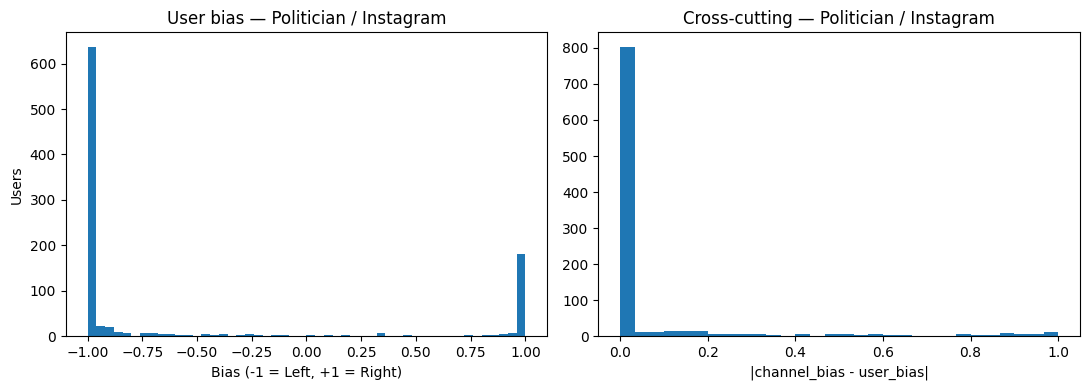

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(user_counts["user_bias"], bins=50)
ax[0].set_title(f"User bias — {PRODUCER_TYPE} / {PLATFORM}")
ax[0].set_xlabel("Bias (-1 = Left, +1 = Right)")
ax[0].set_ylabel("Users")

ax[1].hist(user_counts["user_cross_cut"].dropna(), bins=30)
ax[1].set_title(f"Cross-cutting — {PRODUCER_TYPE} / {PLATFORM}")
ax[1].set_xlabel("|channel_bias - user_bias|")

plt.tight_layout()
plt.show()

### Audience size

`producer_stats.csv` comes from `fetch_audience_size.py` — YouTube subscriber
counts via the Data API, Instagram follower counts via instaloader. If the file
isn't there yet the notebook still runs; `audience_size` is just NaN and the
control drops out of the regressions.

In [13]:
import os

_stats_path = f"{OUT}/producer_stats.csv"

if os.path.exists(_stats_path):
    stats = P.load_producer_stats(_stats_path)
else:
    stats = None
    print("no producer_stats.csv yet -- audience_size will be NaN")

  producer stats: 231 / 260 with a usable count


## 6. Producer- and item-level aggregates

In [14]:
channel_df = P.channel_level(comment_users, PLATFORM, PRODUCER_TYPE, stats)
video_df   = P.video_level(comment_users, PLATFORM, PRODUCER_TYPE, stats)

print("producers:", channel_df.shape)
print("items    :", video_df.shape)

channel_df.head()

  audience_size missing for 6 / 78 rows
  audience_size missing for 571 / 10887 rows
producers: (78, 14)
items    : (10887, 16)


,key,channel_id,channel_name,producer_name,ideology,channel_url,mean_user_bias,mean_cross_cutting,n_comments,n_users,total_likes,audience_size,platform,producer_type
0,015miae,3933396569,015miae,김미애,right,https://www.instagram.com/015miae/,0.891954,0.108046,557,37,551.0,5923.0,Instagram,Politician
1,0hwan_ilsan,6450785429,0hwan_ilsan,김영환,left,https://www.instagram.com/0hwan_ilsan/,-0.969402,0.030598,25,13,16.0,1626.0,Instagram,Politician
2,_jangdonghyuk_,50710800639,_jangdonghyuk_,장동혁,right,https://www.instagram.com/_jangdonghyuk_/,0.795076,0.204924,2614,164,5507.0,28374.0,Instagram,Politician
3,ahn_dogeol,59409884014,ahn_dogeol,안도걸,left,https://www.instagram.com/ahn_dogeol/,-0.791508,0.208492,68,11,13.0,1632.0,Instagram,Politician
4,ahnho065,7679080914,ahnho065,안호영,left,https://www.instagram.com/ahnho065/,-0.802977,0.197023,292,55,271.0,NaN,Instagram,Politician


### Label check

All three outputs must carry the same `producer_type` / `platform`. The
previous notebooks wrote `"YouTuber"` into the politician files and
`"Politician"` into the youtuber user counts, which silently flattened the
group comparison in the regressions.

In [15]:
for name, frame in [("user_counts", user_counts),
                    ("channel_df", channel_df),
                    ("video_df", video_df)]:
    pt, pl = set(frame["producer_type"]), set(frame["platform"])
    ok = pt == {PRODUCER_TYPE} and pl == {PLATFORM}
    print(f"{name:12} {pt} {pl} {'OK' if ok else '<<< MISLABELLED'}")
    assert ok, name

user_counts  {'Politician'} {'Instagram'} OK
channel_df   {'Politician'} {'Instagram'} OK
video_df     {'Politician'} {'Instagram'} OK


## 7. Save

In [16]:
user_counts.to_csv(f"{OUT}/user_counts.csv", index=False, encoding="utf-8-sig")
channel_df.to_csv(f"{OUT}/channel_df.csv", index=False, encoding="utf-8-sig")
video_df.to_csv(f"{OUT}/video_df.csv", index=False, encoding="utf-8-sig")

print("saved to", OUT)

saved to D:/School/2026 Spring/KR_Polarization/dataset/politicians/instagram
